# Caricamento dataset e ispezione 

Seguo il testo del compito ma riadattato alla consegna del preappello

In [19]:
import pandas as pd

df = pd.read_csv("housing.csv")
print(df.head())
print((df.isna().mean() * 100).sort_values(ascending=False))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
total_bedrooms        1.002907
longitude             0.000000
latitude     

# Pipeline di preprocessing

Creeremo una pipeline principale con sub-pipeline per features numeriche e categoriche e in seconda istanza utilizzeremo i modelli embedded per fare una regressione lineare e confronteremo i risultati.



In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge

X = df.drop(columns="median_house_value")
y = df["median_house_value"]

# Split train val test / 80 5 15

# Primo split 80% train, 20% temporaneo
X_train,X_temp ,y_train,y_temp = train_test_split(X,y, random_state=42, test_size=0.20)

# Secondo split del 20% temporaneo:
# 25% diventa validation (5% del totale)
# 75% diventa test (15% del totale)
X_val,X_test,y_val,y_test = train_test_split(X_temp, y_temp, test_size=0.75, random_state=42)

# Gestione feature multicollineari con feature derivate
for X_set in [X_train, X_test, X_val]:
    X_set['population_for_households'] = X_set['population']/X_set['households']
    X_set['rooms_for_households'] = X_set['total_rooms']/X_set['households']


cat_features = X_train.select_dtypes(include=['object','string','category']).columns
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first",handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
X_val_processed = preprocessor.transform(X_val)

# Analisi features multicollineari tramite matrice di correlazione

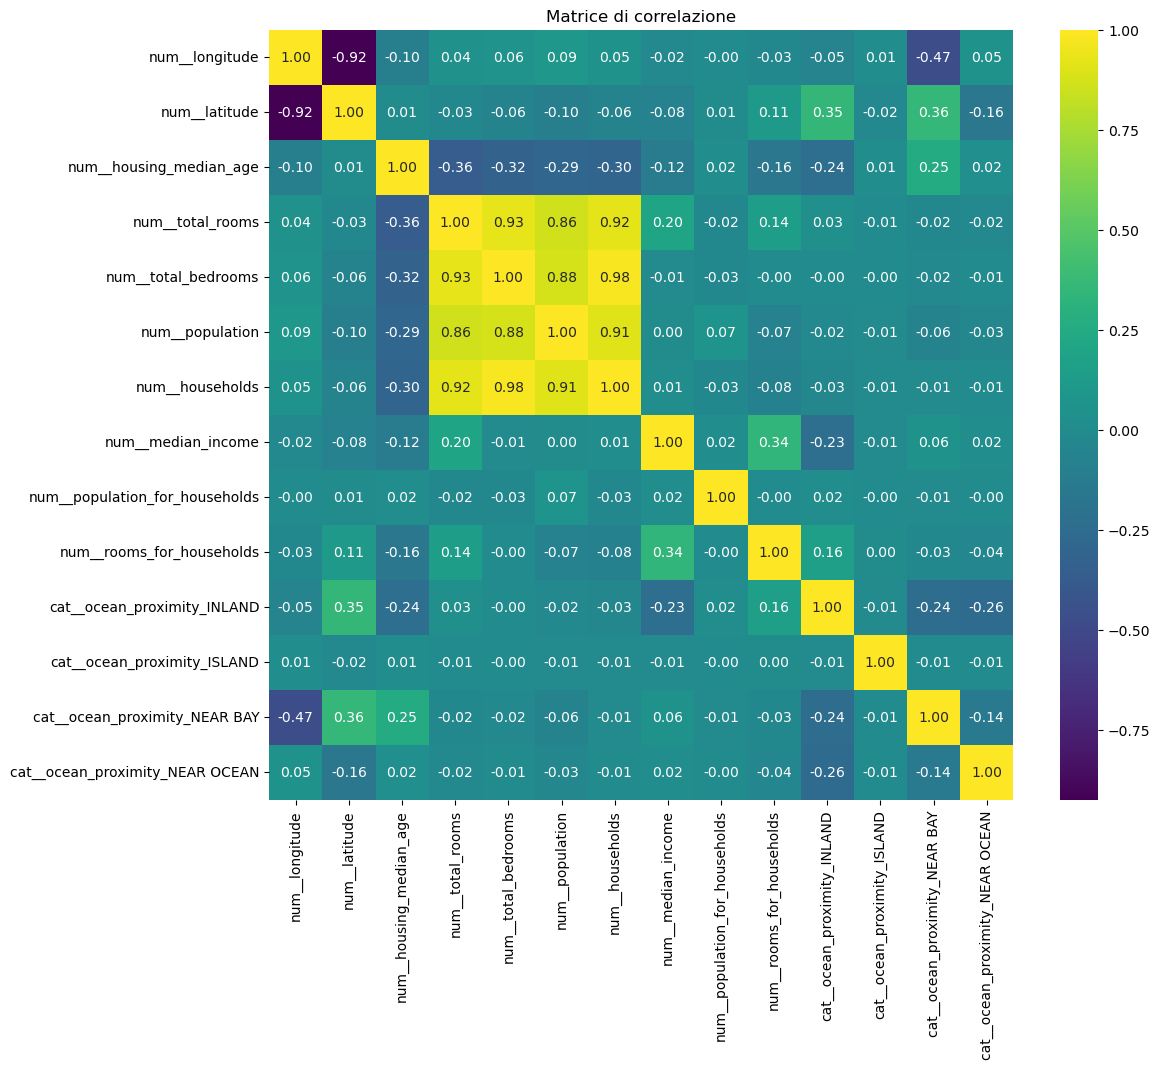

-0.9244852138892324 num__longitude num__latitude
0.9304892875010854 num__total_rooms num__total_bedrooms
0.8579357376244672 num__total_rooms num__population
0.9204816176035046 num__total_rooms num__households
0.8789323939506193 num__total_bedrooms num__population
0.9802545152967787 num__total_bedrooms num__households
0.907451739052402 num__population num__households


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train_processed.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='viridis', annot=True, fmt=".2f")
plt.title("Matrice di correlazione")
plt.show()

# Osserviamo le features che hanno una correlazione superiore alla soglia
for i, col1 in enumerate(corr_matrix.columns):
    for col2 in corr_matrix.columns[i+1:]:
        if col1!=col2:
            val_corr=corr_matrix.loc[col1,col2]
            if abs(val_corr) > 0.80:
                print(val_corr, col1, col2)

cols_to_drop = ['num__households', 'num__population', 'num__total_rooms']

X_train_processed = X_train_processed.drop(columns=cols_to_drop)    
X_test_processed = X_test_processed.drop(columns=cols_to_drop)    
X_val_processed = X_val_processed.drop(columns=cols_to_drop)    


In [22]:

for X_set in [X_train_processed, X_test_processed, X_val_processed]:
    missing_values_train = X_train_processed.isnull().sum().sum()
    missing_values_val = X_val_processed.isnull().sum().sum()
    missing_values_test = X_test_processed.isnull().sum().sum()


print(f"Dimensioni X_train_processed: {X_train_processed.shape}")
print(f"Valori mancanti train: {missing_values_train} ")
print(f"Valori mancanti test: {missing_values_test} ")
print(f"Valori mancanti val: {missing_values_val} ")

print(X_train_processed.head())
print(X_train_processed.columns.tolist())

Dimensioni X_train_processed: (16512, 11)
Valori mancanti train: 0 
Valori mancanti test: 0 
Valori mancanti val: 0 
       num__longitude  num__latitude  num__housing_median_age  \
14196        1.272587      -1.372811                 0.348490   
8267         0.709162      -0.876696                 1.618118   
17445       -0.447603      -0.460146                -1.952710   
14265        1.232698      -1.382172                 0.586545   
2271        -0.108551       0.532084                 1.142008   

       num__total_bedrooms  num__median_income  \
14196             0.211228           -0.326196   
8267              0.593094           -0.035843   
17445            -0.495226            0.144701   
14265            -0.409306           -1.017864   
2271             -0.256559           -0.171488   

       num__population_for_households  num__rooms_for_households  \
14196                        0.051376                  -0.174916   
8267                        -0.117362                  

# Feature selection con Lasso


In [26]:
from sklearn.feature_selection import SelectFromModel

lasso = Lasso(alpha=3000, max_iter=1000, random_state=42)
selector = SelectFromModel(estimator=lasso)

X_train_sel = selector.fit_transform(X_train_processed, y_train)
X_test_sel = selector.transform(X_test_processed)
X_val_sel = selector.transform(X_val_processed)

selected_features = X_train_processed.columns[selector.get_support()].tolist()

print(f"Features selezionate: {selected_features}")
print(f"Nuova shape: {X_train_sel.shape}")


Features selezionate: ['num__longitude', 'num__housing_median_age', 'num__total_bedrooms', 'num__median_income', 'num__population_for_households', 'cat__ocean_proximity_INLAND']
Nuova shape: (16512, 6)


# Regressione Ridge e GridSearchCV

In [27]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid_ridge = {
    'alpha' : [0.01, 0.1, 1]
}

ridge = Ridge()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    # Essendo regressione con scoring useremo RMSE e non Accuracy
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

grid_ridge.fit(X_train_sel, y_train)

best_model = grid_ridge.best_estimator_
best_params = grid_ridge.best_params_
y_pred_ridge = grid_ridge.predict(X_test_sel)

# Calcolo delle metriche 
from sklearn.metrics import mean_squared_error, root_mean_squared_error,r2_score

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Best model:{best_model}")
print(f"Best params:{best_params}")
print(f"MSE:{mse_ridge:.2f}")
print(f"RMSE:{rmse_ridge:.2f}")
print(f"R2:{r2_ridge:.2f}")

# Adesso effettuaimo regressione con RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor

param_grid_rfg = {
    'n_estimators' : [50,100,200]
}

rfg = RandomForestRegressor()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_rfg = GridSearchCV(
    estimator=rfg,
    param_grid=param_grid_rfg,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

grid_rfg.fit(X_train_sel, y_train)

best_model_rfg = grid_rfg.best_estimator_
best_params_rfg = grid_rfg.best_params_
y_pred_rfg = grid_rfg.predict(X_test_sel)

mse_rfg = mean_squared_error(y_test, y_pred_rfg)
rmse_rfg = root_mean_squared_error(y_test, y_pred_rfg)
r2_rfg = r2_score(y_test, y_pred_rfg)

print(f"Best model:{best_model_rfg}")
print(f"Best params:{best_params_rfg}")
print(f"MSE:{mse_rfg:.2f}")
print(f"RMSE:{rmse_rfg:.2f}")
print(f"R2:{r2_rfg:.2f}")

Best model:Ridge(alpha=1)
Best params:{'alpha': 1}
MSE:5284773603.92
RMSE:72696.45
R2:0.60
Best model:RandomForestRegressor(n_estimators=200)
Best params:{'n_estimators': 200}
MSE:2990763644.83
RMSE:54687.87
R2:0.77


# Creazione rete neurale 

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import torchnn as tnn




class HouseData(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(np.array(X), dtype=torch.float32)
        self.y=torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1) # unsqueeze crea un tensore bidimensionale
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

train_data = HouseData(X_train_sel, y_train)
val_data = HouseData(X_val_sel,y_val)
test_data = HouseData(X_test_sel, y_test)

# DataLoader 
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class HouseNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16,1),
        )
    def forward(self,x):
        return self.layers(x)

input_dim = X_train_sel.shape[1]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Dispositivo in uso: {device}")

model = HouseNet(input_dim=input_dim).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=1e-4, momentum=0.1, centered=True)
scheduler = optim.lr_scheduler.LinearLR(optimizer=optimizer, start_factor=0.01)
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.01)
train_loss, val_loss, test_loss, test_metrics= tnn.train_test(
    model=model,
    optimizer=optimizer,
    device=device,
    train_dataloader=train_loader,
    test_dataloader=train_loader,
    epochs=50,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    early_stopping=early_stopping,
    val_dataloader=val_loader,
    scheduler=scheduler,
    metrics=[],
    average='macro'
)

torch.save(model.state_dict(), 'models/best_model.pt')

    

# salvataggio plot metriche

In [ ]:
model.load_state_dict(torch.load("models/best_model.pt"))

#TODO